# Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, I will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset.

This project demostrates competency in the following learning objectives:

- Loading, exploring, and preparing a text dataset for training a transformer model using PyTorch.
- Customizing the architecture of the transformer model for a classification task.
- Training and testing a transformer model on the IMDB dataset.

---

### Project Outline

This notebook is organized into the following sections:


1. Introduction: Overview of the project, learning objectives, and understanding sentiment analysis.
2. Load, Explore, and Prepare the Dataset: Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. Implement a DataLoader in PyTorch: Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. Transformer Architecture: Build a custom transformer model for binary classification.
5. Implement Accuracy Calculation Method: Create a function to compute accuracy for monitoring performance.
6. Train the Model: Complete and execute the training loop for binary classification.
7. Test the Model: Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. Conclusion: Summarize the project results and key takeaways.

---

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, we will classify IMDB movie reviews as positive or negative to enhance a recommendation system, enabling more accurate and personalized suggestions.

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture.

---

### Data Description

The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/). Data folder structure.

```
aclIMDB/
├── train/
│   ├── pos/    # Positive reviews for training
│   ├── neg/    # Negative reviews for training
│   ├── unsup/  # Unsupervised data (not used in this project)
├── test/
│   ├── pos/    # Positive reviews for testing
│   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

---


### 1. Load the Dataset

In [ ]:
import os
import pandas as pd

In [ ]:
!tar -xzf aclImdb_v1.tar.gz

In [ ]:
# Define paths to dataset
train_pos_path = 'aclImdb/train/pos'
train_neg_path = 'aclImdb/train/neg'
test_pos_path = 'aclImdb/test/pos'
test_neg_path = 'aclImdb/test/neg'

In [ ]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """

    reviews_list = []

    for filename in sorted(os.listdir(folder)):

        if filename.endswith(".txt"):
            filepath = os.path.join(folder, filename)
            with open(filepath, "r", encoding="utf-8") as file:
                review = file.read()
            reviews_list.append(review)

    return reviews_list

In [ ]:
# Load training and testing data
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

In [ ]:
print(train_pos[-1])

Working-class romantic drama from director Martin Ritt is as unbelievable as they come, yet there are moments of pleasure due mostly to the charisma of stars Jane Fonda and Robert De Niro (both terrific). She's a widow who can't move on, he's illiterate and a closet-inventor--you can probably guess the rest. Adaptation of Pat Barker's novel "Union Street" (a better title!) is so laid-back it verges on bland, and the film's editing is a mess, but it's still pleasant; a rosy-hued blue-collar fantasy. There are no overtures to serious issues (even the illiteracy angle is just a plot-tool for the ensuing love story) and no real fireworks, though the characters are intentionally a bit colorless and the leads are toned down to an interesting degree. The finale is pure fluff--and cynics will find it difficult to swallow--though these two characters deserve a happy ending and the picture wouldn't really be satisfying any other way. *** from ****


We can convert the data into pandas dataframes to make handling the datasets easier.

In [ ]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1


### 2. Explore the Dataset


In [ ]:
print(f"Training dataset info: {train_df.info()}\n")
print(f"Testing dataset info: {test_df.info()}\n")
print("\n")
print(f"Training dataset stats: {train_df.describe()}\n")
print(f"Testing dataset stats: {test_df.describe()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
Training dataset info: None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
Testing dataset info: None



Training dataset stats:              label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000
50%        0.50000
75%        1.00000
max        1.00000

Testing dataset stats:              label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000


In [ ]:
print("POSITIVE REVIEW:\n")
print(train_df[train_df["label"] == 1]["review"].iloc[0])

print("\n" + "=" * 80 + "\n")

print("NEGATIVE REVIEW:\n")
print(train_df[train_df["label"] == 0]["review"].iloc[0])

POSITIVE REVIEW:

Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!


NEGATIVE REVIEW:

Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audien

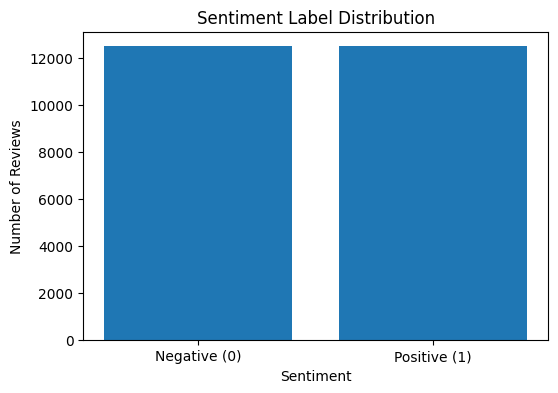

In [ ]:
import matplotlib.pyplot as plt

label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Negative (0)", "Positive (1)"], label_counts.values)
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

### 3. Prepare the Dataset
We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.


In [ ]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))

# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

In [ ]:
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))

Training samples: 22500
Validation samples: 2500


### 4. Testing the Tokenizer


In [ ]:
from transformers import AutoTokenizer

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(
    sample_texts, truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt")

In [ ]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  2348,  1996,  3185,  2003,  4415,  6052,  1010,  9501,  2064,
          2145,  4089,  6709,  2007,  1996, 24525,  1997,  5292, 21112,  2015,
         18396,  1999,  2023, 27768,  1998,  2200,  6057,  2104, 16168,  6925,
          1012, 18396,  9590,  2114,  4895, 18824,  2135, 10238,  1999,  2093,
          2367,  5535,  1024,  1996,  2962,  2287,  1010,  1996,  3142,  2287,
          1010,  1998,  1996,  5549,  2078,  2287,  1010,  2652,  2471,  1996,
          2168,  2839,  2007,  2074,  1037,  2689,  1997, 17363,  2000,  2393,
          2149,  6709,  1996,  2367,  1000,  5535,  1000,  1012,  1999,  2023,
          3185,  2057,  2156,  2028,  1997,  1996,  5700, 21699, 20818,  1997,
          1996,  1000,  5430,  2386,  1000, 12991, 13874,  1010,  2040,  5222,
          2010,  2293,  2025,  2011,  7472,  2021,  2011, 26128,  2486,  1010,
          2004,  2092,  2004,  1037,  6057,  9792,  2006,  3142,  5580,  2401,
         29469,  2389,  4337,  1010,  

Explanation of parameters:
 - `truncation=True`: Truncates text longer than the specified max_length.
 - `padding=True`: Pads shorter sequences to match max_length.
 - `max_length=128`: Specifies the maximum length of the sequences.
 - `return_tensors="pt"`: Returns PyTorch tensors as the output format.




### 1. Define a Custom Dataset Class

The custom dataset class will inherit from `torch.utils.data.Dataset` and include the following features:

1. **Initialization (`__init__`)**:
   - Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
   - The tokenizer is used to preprocess the text data into tokenized inputs.
   - The maximum sequence length ensures that all tokenized inputs are of uniform length.

2. **Length (`__len__`)**:
   - Returns the total number of data samples in the dataset.

3. **Item Retrieval (`__getitem__`)**:
   - Retrieves a single data point by index.
   - Preprocesses the text using the tokenizer to create tokenized input IDs.
   - Returns the tokenized input IDs and the corresponding label for the given index.

[More info](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) tutorial on the Pytorch website for more details.


In [ ]:
import torch
from torch.utils.data import Dataset
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to 128.
        """
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        review, label = self.data.iloc[idx]["review"], self.data.iloc[idx]["label"]
        encoding = self.tokenizer(
            review,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        label = torch.tensor(label, dtype=torch.long)

        return input_ids, label

### 2. Initialize the Dataset

Once the `IMDBDataset` class is defined, we can initialize it directly with the training and validation DataFrames.

In [ ]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

In [ ]:
# Retrieve one sample

input_ids, label = train_dataset[0]

print("Input IDs shape:", input_ids.shape)
print("Label:", label)
print("Input IDs dtype:", input_ids.dtype)
print("Label dtype:", label.dtype)

Input IDs shape: torch.Size([128])
Label: tensor(1)
Input IDs dtype: torch.int64
Label dtype: torch.int64


### 3. Create a DataLoader

The `DataLoader` class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [ ]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Get one batch from the training DataLoader
input_ids, labels = next(iter(train_loader))

print("Input IDs shape:", input_ids.shape)
print("Labels shape:", labels.shape)
print("First five labels:", labels[:5])

Input IDs shape: torch.Size([32, 128])
Labels shape: torch.Size([32])
First five labels: tensor([1, 0, 1, 0, 0])


In [ ]:
# Test the dataset
input_ids, label = train_dataset[0]

assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, torch.Tensor), "Label should be a torch.Tensor!"
assert label.dtype == torch.long, "Label tensor should have dtype torch.long!"
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

print("Dataset test passed!")
print("Input IDs shape:", input_ids.shape)
print("Label:", label)

Dataset test passed!
Input IDs shape: torch.Size([128])
Label: tensor(1)


## Customize the Transformer Architecture

In this section, we will built a custom transformer architecture to suit the task of binary classification.
### 1. Config Dictionary
Config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [ ]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 256,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 8,
    "head_size": 32,                         # 8 heads * 32 = 256 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

Key Config Parameters:
- `vocabulary_size`: The total number of tokens in your vocabulary.
- `num_classes`: The number of classes for the classification head (2 = binary).
- `d_embed`: Dimensionality of embeddings (and hidden layers).
- `context_size`: Maximum sequence length for each input.
- `layers_num`: Number of stacked transformer blocks.
- `heads_num`: Number of attention heads in multi-head attention.
- `head_size`: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).
- `dropout_rate`: Probability of dropping units during training to reduce overfitting.
- `use_bias`: Whether linear layers should have bias terms.



### 2. Class Definitions


#### AttentionHead

In [ ]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

Here we use a dummy input aligned with our config:

- Batch size = `BATCH_SIZE` (32)
- Sequence length = `config["context_size"]` (128)
- Embedding dimension = `config["d_embed"]` (128)


In [ ]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create a dummy input of shape (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 128, 32])


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                    # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [ ]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 128, 256])


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [ ]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 128, 256])


In [ ]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [ ]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 128, 256])


### Key Changes for Binary Classification

To adapt the transformer for classification, the following changes are required:

1. **Add a Classification-Specific Output Layer**:
   - The model needs a linear layer to map the final pooled embeddings to the number of classes.
   - The classification head is implemented using [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) with:
     - `in_features` set to `d_embed` (the embedding dimension).
     - `out_features` set to `num_classes` (the number of classes, 2 for binary classification).
     - `bias` set to `False` (optional; bias can be excluded to slightly simplify computations).


2. **Implement a Pooling Mechanism**:

   - Transformers output embeddings for each token in the input sequence. For classification, these token-level embeddings need to be condensed into a single vector.

   - A **mean pooling operation** is applied using [`torch.mean`](https://pytorch.org/docs/stable/generated/torch.mean.html) across the time dimension (`dim=1`) to aggregate token-level embeddings into a single representation vector.

In [ ]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])

        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])

        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)

        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])

        # Implement classification output layer - Maps pooled embeddings to class logits.
        self.classification_head = nn.Linear(
                                    config["d_embed"],
                                    config["num_classes"],
                                    bias=False
                                )

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T),
                                    where B is the batch size, and T is the sequence length.

        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings

        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension

        # Step 3: Apply mean pooling across the time dimension  # Shape: (B, d_embed)
        x = torch.mean(x, dim=1)

        # Step 4: Generate logits for classification  # Shape: (B, num_classes)
        logits = self.classification_head(x)

        return logits

In [ ]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"],
    (BATCH_SIZE, config["context_size"])
    ).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[-0.0441, -0.1001],
        [ 0.0797, -0.0827]], device='cuda:0', grad_fn=<SliceBackward0>)


In [ ]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method

### 1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

### 2.  Key Points
- **Evaluation Mode**: Calling `model.eval()` ensures that dropout and other training-specific layers are disabled during evaluation.
- **No Gradients**: The `torch.no_grad()` context disables gradient computation, reducing memory usage and speeding up validation.
- **Predictions**: `torch.argmax(logits, dim=1)` retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- **Accuracy Calculation**: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.



In [ ]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
    model (torch.nn.Module): The trained transformer model.
    data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
    device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
    float: Validation accuracy as a percentage.
    """

    model.eval()

    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(input_ids)

            # Get predicated classes
            # Ensure logits have shape [batch_size, num_classes]
            predictions = torch.argmax(logits, dim=-1)

            # Count correct predictions
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100

    return accuracy

In [ ]:
model = DemoGPT(config).to(device)

In [ ]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 49.88%


## Train the Model

### Training Loop

The training loop will involve the following steps:

1. **Iterate through epochs**: Repeat the training process for a predefined number of epochs.
2. **Load batches of data**: Use the `DataLoader` to retrieve batches of input IDs and labels.
3. **Forward pass**: Compute the logits by passing the input IDs through the model.
4. **Compute loss**: Use cross-entropy loss as the criterion.
5. **Backward pass and optimization**: Backpropagate the loss and update the model parameters using the optimizer.
6. **Validation**: Calculate the validation accuracy after each epoch.


In [ ]:
import torch.optim as optim

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
EPOCHS = 4

# Initialize model, loss, and optimizer
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

# Training loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        # Move data to device
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(input_ids)

        # Calculate loss
        loss = criterion(logits, labels)

        # Set gradients to zero
        optimizer.zero_grad()

        # Backward pass
        loss.backward()

        # Step the optimizer
        optimizer.step()

        running_loss += loss.item()

        # Log training progress
        if (step + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], "
                  f"Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}")

            running_loss = 0.0

    # Evaluate validation accuracy
    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/4], Step [100/704], Loss: 0.6986
Epoch [1/4], Step [200/704], Loss: 0.6564
Epoch [1/4], Step [300/704], Loss: 0.6158
Epoch [1/4], Step [400/704], Loss: 0.5683
Epoch [1/4], Step [500/704], Loss: 0.5563
Epoch [1/4], Step [600/704], Loss: 0.5370
Epoch [1/4], Step [700/704], Loss: 0.5031
Epoch 1 - Validation Accuracy: 75.36%
Epoch [2/4], Step [100/704], Loss: 0.4692
Epoch [2/4], Step [200/704], Loss: 0.4527
Epoch [2/4], Step [300/704], Loss: 0.4680
Epoch [2/4], Step [400/704], Loss: 0.4617
Epoch [2/4], Step [500/704], Loss: 0.4450
Epoch [2/4], Step [600/704], Loss: 0.4377
Epoch [2/4], Step [700/704], Loss: 0.4384
Epoch 2 - Validation Accuracy: 78.48%
Epoch [3/4], Step [100/704], Loss: 0.3725
Epoch [3/4], Step [200/704], Loss: 0.3732
Epoch [3/4], Step [300/704], Loss: 0.3971
Epoch [3/4], Step [400/704], Loss: 0.3846
Epoch [3/4], Step [500/704], Loss: 0.3651
Epoch [3/4], Step [600/704], Loss: 0.3698
Epoch [3/4], Step [700/704], Loss: 0.3616
Epoch 3 - Validation Accuracy: 79.64%
Epoc

## Test the Model

In [ ]:
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 78.11%


In [ ]:
# Save the model

torch.save({"model_state_dict": model.state_dict(),
           "config": config},
          "sentiment_scope_model_#1.pth")

print("Model saved.")

Model saved.


In [ ]:
# Load the saved model

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved checkpoint
checkpoint = torch.load(
            "sentiment_scope_model_#1.pth",
            map_location=device,
            weights_only=False
            )

# Retrive the configuration
config = checkpoint["config"]

# Recreate the model architecture
model = DemoGPT(config).to(device)

# Load the learned weights
model.load_state_dict(checkpoint["model_state_dict"])

# Set model to evalution mode
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# Prediction function

def predict_sentiment(review, model, tokenizer, device):
    model.eval()

    encoding = tokenizer(
        review,
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)

    with torch.no_grad():
        logits = model(input_ids)
        prediction = torch.argmax(logits, dim=-1).item()

    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment

In [ ]:
print(test_df.head())

                                              review  label
0  I went and saw this movie last night after bei...      1
1  Actor turned director Bill Paxton follows up h...      1
2  As a recreational golfer with some knowledge o...      1
3  I saw this film in a sneak preview, and it is ...      1
4  Bill Paxton has taken the true story of the 19...      1


In [ ]:
print(test_df.tail())

                                                  review  label
24995  I occasionally let my kids watch this garbage ...      0
24996  When all we have anymore is pretty much realit...      0
24997  The basic genre is a thriller intercut with an...      0
24998  Four things intrigued me as to this film - fir...      0
24999  David Bryce's comments nearby are exceptionall...      0


In [ ]:
index = 24916
print(test_df["review"][index])
print(test_df["label"][index])

This one is a bit more stylish than the average erotic thriller and Peta Wilson is a very sexy presence but it plays like they lost a few pages of script somewhere. Subplots come in and out of nowhere, the connections between some of the characters are murky and the killer's motivation is unclear to say the least. Maybe they could get away with this in a porn version, but here some more clarification is needed.
0


In [ ]:
review = test_df["review"][345]

result = predict_sentiment(
    review,
    model,
    tokenizer,
    device
)

print("Predicted sentiment:", result)

Predicted sentiment: Negative


## Conclusion <a name="conclusion"></a>

#### 1. Project Results (Summary)

- The model was trained for 4 epochs, with 704 training steps per epoch. During training, the loss generally decreased, indicating that the model was learning patterns associated with positive and negative sentiment.
- The validation accuracy improved from 75.36% in Epoch 1 to 80.20% in Epoch 4, representing an improvement of 8.36 percentage points.
- The model achieved a final test accuracy of 78.11% on the IMDB test dataset, and this indicates that the trained model was able to classify sentiment in previously unseen movie reviews.
- The results demonstrate the potential of Transformer-based architectures for sentiment classification.
- Further experimentation with training epochs, model architecture, and hyperparameters could be used to investigate potential performance improvements.
- Overall, the project provided practical experience in natural language processing, Transformer architectures, PyTorch model training, and sentiment classification evaluation.

#### 2. Key Takeways

1. Text preprocessing and tokenization are essential for Natural Language Processing tasks.
2. Transformers can capture relationships between tokens in text.
3. PyTorch Data Loaders simplify batch processing.
4. Cross Entropy Loss is suitable for multi-class classification.
5. Validation accuracy helps monitor model performance.
6. Test accuracy provides an indication of generalization to unseen data.
7. Lastly, the model performance can potentially be improved through hyperparameter tuning, more training epochs.